In [10]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense 
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model

In [11]:
diabetes = datasets.load_diabetes()


(442, 1)
(442,)


Text(0, 0.5, 'Disease progression')

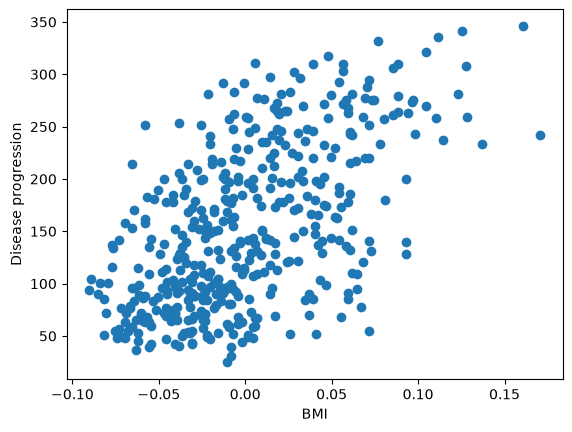

In [12]:
diabetes['feature_names']
features = diabetes.data[:,2:3]

len(features)
print(features.shape)
features = np.squeeze(features)
print(features.shape)
targets = diabetes.target
plt.scatter(features,targets)
plt.xlabel("BMI")
plt.ylabel("Disease progression")

In [13]:

inputs = Input(shape=(1,))
output = Dense(1, activation='linear')(inputs)

linear_model = Model(inputs, output)

linear_model.summary()

linear_model.compile(optimizer='sgd', loss='mse')



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
EPOCH = 1000
r = linear_model.fit(features, targets, epochs=EPOCH)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24024.1035  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16210.2842 
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11747.1729 
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9225.1221 
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7802.1021 
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6986.9185 
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6528.6309 
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6262.3550 
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6112.5405 
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6023.7319 
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5975.8872 
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5942.4116 
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5923.6675 
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5916.174

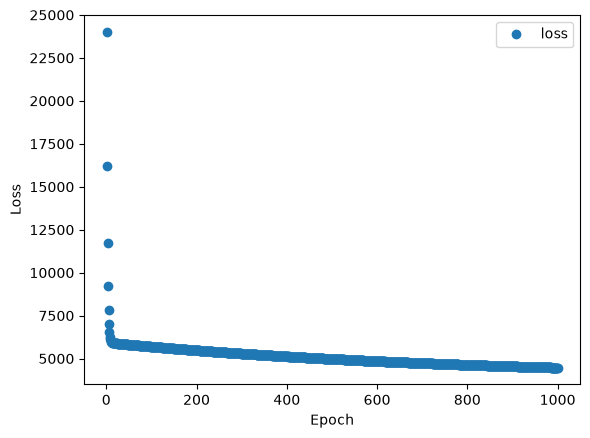

In [15]:
x = np.linspace(1,EPOCH,EPOCH)
plt.plot(x, r.history['loss'],'o', label='loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


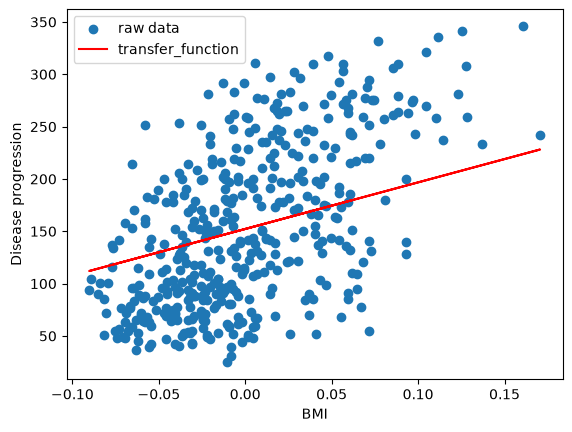

In [16]:
pred = linear_model.predict(features)


# In[17]:


plt.scatter(features,targets, label = 'raw data')
plt.plot(features,pred,'r', label = "transfer_function")
plt.xlabel("BMI")
plt.ylabel("Disease progression")
plt.legend()


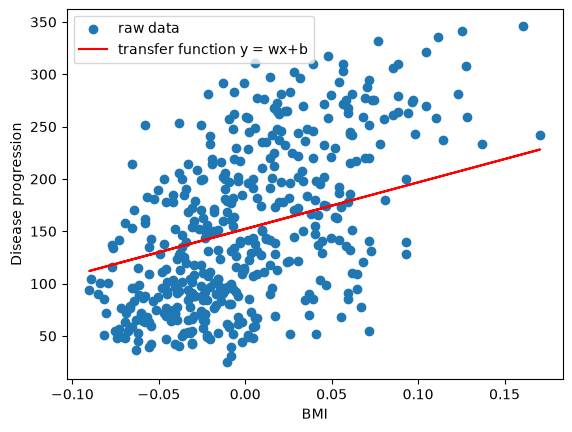

In [17]:
weight = linear_model.get_weights()[0].item()
bias = linear_model.get_weights()[1].item()

plt.scatter(features, targets, label='raw data')
plt.plot(features, weight * features + bias, 'r', label='transfer function y = wx+b')
plt.xlabel("BMI")
plt.ylabel("Disease progression")
plt.legend()

In [18]:
# introduce the new feature: BMI (index 2) + Blood Pressure (index 3)
features_2d = diabetes.data[:, 2:4]
print("features_2d shape:", features_2d.shape)

features_2d shape: (442, 2)


Text(0, 0.5, 'Disease progression')

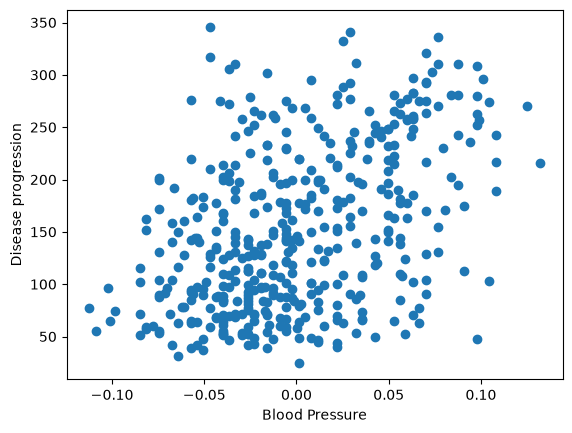

In [19]:
# observing the correlation between BP and progression
x = features_2d[:, 1]
y = targets
plt.scatter(x, y)
plt.xlabel("Blood Pressure")
plt.ylabel("Disease progression")

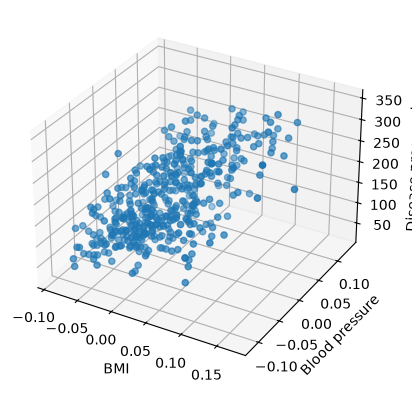

In [20]:
# observing the correlation between BMI & BP and diabetes progression
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = features_2d[:, 0]
y = features_2d[:, 1]
z = targets

ax.set_xlabel('BMI')
ax.set_ylabel('Blood pressure')
ax.set_zlabel('Disease progression')
ax.scatter(x, y, z, marker='o')

In [21]:
# single neuron with 2 inputs (BMI + Blood Pressure)
inputs = Input(shape=(2,))
output = Dense(1, activation='linear')(inputs)

linear_model_bmi_bp = Model(inputs, output)
linear_model_bmi_bp.summary()

linear_model_bmi_bp.compile(optimizer='sgd', loss='mse')

EPOCH = 1000
r_2d = linear_model_bmi_bp.fit(features_2d, targets, epochs=EPOCH)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24031.6367  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16216.0234 
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11768.8125
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9221.0635 
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7785.1416 
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6973.6709 
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6503.3364 
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6242.3271 
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6092.8350 
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6011.3955 
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5958.2788 
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5925.6646 
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5906.5713 
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5894.3149

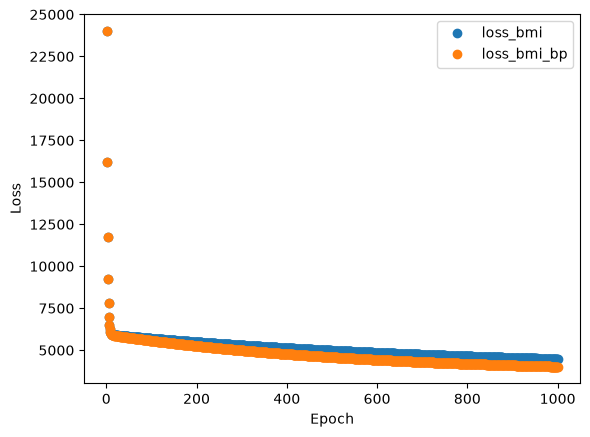

In [22]:
# compare loss: BMI only vs BMI+BP (full range)
x = np.linspace(1, EPOCH, EPOCH)
plt.plot(x, r.history['loss'], 'o', label='loss_bmi')
plt.plot(x, r_2d.history['loss'], 'o', label='loss_bmi_bp')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

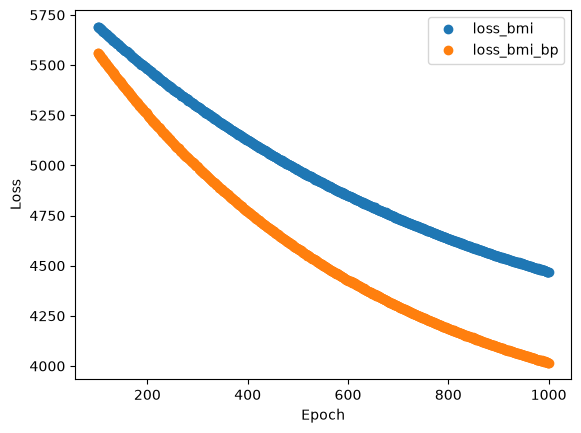

In [23]:
# compare loss: epoch 100-1000 (zoomed)
x = np.linspace(1, EPOCH, EPOCH)
plt.plot(x[100:1000], r.history['loss'][100:1000], 'o', label='loss_bmi')
plt.plot(x[100:1000], r_2d.history['loss'][100:1000], 'o', label='loss_bmi_bp')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

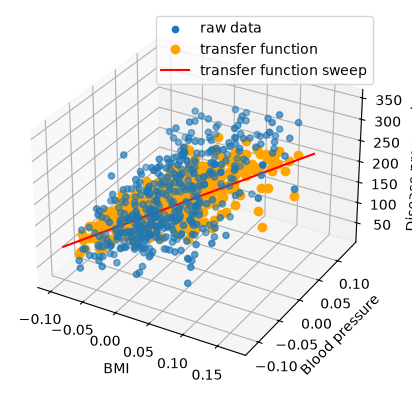

In [24]:
# visualize the learned transfer function in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

weight_1 = linear_model_bmi_bp.get_weights()[0][0].item()
weight_2 = linear_model_bmi_bp.get_weights()[0][1].item()
bias = linear_model_bmi_bp.get_weights()[1].item()

x = features_2d[:, 0]
y = features_2d[:, 1]
z = targets
xx = np.linspace(-0.1, 0.15, 1000)
yy = np.linspace(-0.1, 0.1, 1000)

ax.set_xlabel('BMI')
ax.set_ylabel('Blood pressure')
ax.set_zlabel('Disease progression')

ax.scatter(x, y, z, marker='o', label='raw data')
ax.plot(x, y, weight_1 * x + weight_2 * y + bias, 'o', color='orange', label='transfer function')
ax.plot(xx, yy, weight_1 * xx + weight_2 * yy + bias, color='r', label='transfer function sweep')

plt.legend()

In [25]:
linear_model_bmi_bp.save("Lab_3_neuron.h5")
linear_model_bmi_bp.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Step 11: Model Optimization — All 10 Features

In [26]:
# experiments with all 10 features
features_all = diabetes.data
print("feature names:", diabetes.feature_names)
print("shape:", features_all.shape)

inputs = Input(shape=(10,))
output = Dense(1, activation='linear')(inputs)

linear_model_all = Model(inputs, output)
linear_model_all.summary()

linear_model_all.compile(optimizer='sgd', loss='mse')

EPOCH = 1000
r_all = linear_model_all.fit(features_all, targets, epochs=EPOCH)

feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
shape: (442, 10)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24009.5684  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16151.8936 
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11729.9561 
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9213.3848  
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7772.3633 
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6952.2773 
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6473.5073 
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6198.1460 
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6033.6641 
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5940.2432 
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5880.2388 
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5844.3403 
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5818.1416 
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5802.39

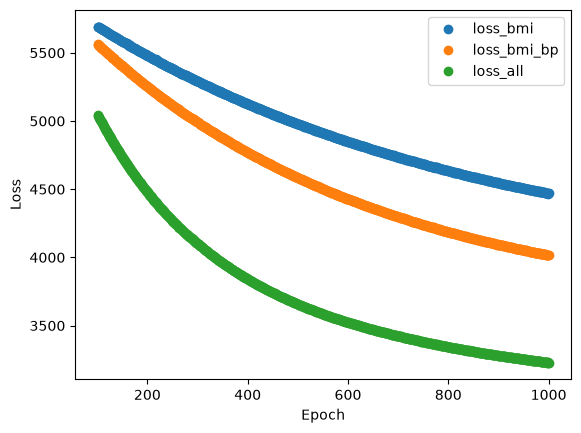

In [27]:
# compare all three models (zoomed to epoch 100-1000)
x = np.linspace(1, EPOCH, EPOCH)
plt.plot(x[100:1000], r.history['loss'][100:1000], 'o', label='loss_bmi')
plt.plot(x[100:1000], r_2d.history['loss'][100:1000], 'o', label='loss_bmi_bp')
plt.plot(x[100:1000], r_all.history['loss'][100:1000], 'o', label='loss_all')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## Step 11: Further Optimization — Adam Optimizer + Hidden Layers

Two improvements:
1. **Adam optimizer** instead of SGD — adapts the learning rate, converges faster
2. **Hidden layer** with ReLU — models non-linear relationships between features and target

In [28]:
# Optimization experiment: deeper model + Adam optimizer on all 10 features
inputs = Input(shape=(10,))
h = Dense(64, activation='relu')(inputs)
h = Dense(32, activation='relu')(h)
output = Dense(1, activation='linear')(h)

optimized_model = Model(inputs, output)
optimized_model.summary()

optimized_model.compile(optimizer='adam', loss='mse')

EPOCH = 1000
r_opt = optimized_model.fit(features_all, targets, epochs=EPOCH, verbose=0)
print(f"Final loss: {r_opt.history['loss'][-1]:.2f}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Final loss: 2642.18


Text(0.5, 1.0, 'Model Comparison')

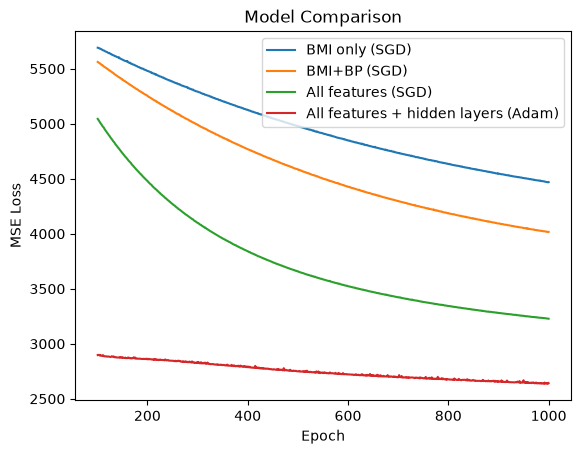

In [29]:
# compare all models: BMI, BMI+BP, all features (linear), all features (deep+Adam)
x = np.linspace(1, EPOCH, EPOCH)
plt.plot(x[100:], r.history['loss'][100:], label='BMI only (SGD)')
plt.plot(x[100:], r_2d.history['loss'][100:], label='BMI+BP (SGD)')
plt.plot(x[100:], r_all.history['loss'][100:], label='All features (SGD)')
plt.plot(x[100:], r_opt.history['loss'][100:], label='All features + hidden layers (Adam)')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Model Comparison")